# Phase 4: Feature Engineering - Lags and Windows

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configure plotting style
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load Aggregated Dataset
We continue by loading the hourly aggregated demand dataset base.

In [2]:
processed_dir = Path("../data/processed")
base_ts_path = processed_dir / "base_hourly_demand.parquet"

# Load and ensure index is sorted datetime
df = pd.read_parquet(base_ts_path)
if 'timestamp' in df.columns:
    df.set_index('timestamp', inplace=True)

df.sort_index(inplace=True)

print(f"Loaded Time Series with shape: {df.shape}")
df.head()

Loaded Time Series with shape: (10177, 1)


,total_demand
timestamp,
2025-01-01 00:00:00,6610
2025-01-01 01:00:00,7481
2025-01-01 02:00:00,6126
2025-01-01 03:00:00,3840
2025-01-01 04:00:00,2369


## 2. Generate Lag Features
We create features representing the demand at previous time steps. Common lags for hourly data include previous hours ($t-1, t-2, t-3$) and seasonal periods ($t-24$ for previous day, $t-168$ for previous week).

In [3]:
lags = [1, 2, 3, 24, 48, 168]

for lag in lags:
    df[f'lag_{lag}'] = df['total_demand'].shift(lag)

# Inspect the tails to ensure lags populated correctly
df.tail()

,total_demand,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168
timestamp,,,,,,,
2026-02-28 20:00:00,7594,9639.0,9526.0,7894.0,8670.0,8865.0,7688.0
2026-02-28 21:00:00,7760,7594.0,9639.0,9526.0,8089.0,9296.0,6855.0
2026-02-28 22:00:00,9212,7760.0,7594.0,9639.0,8403.0,7451.0,8088.0
2026-02-28 23:00:00,9141,9212.0,7760.0,7594.0,8147.0,5478.0,9212.0
2026-03-01 00:00:00,3,9141.0,9212.0,7760.0,7301.0,3131.0,7833.0


## 3. Rolling Window Statistics
Rolling windows capture short-term and medium-term trends and volatility.
We compute the moving average and moving standard deviation over different hour windows (e.g., 6h, 12h, 24h).

In [4]:
windows = [6, 12, 24, 168]

for w in windows:
    # Using closed='left' ensures we only use PAST data, preventing data leakage
    rolling_w = df['total_demand'].rolling(window=w, closed='left')

    df[f'rolling_mean_{w}'] = rolling_w.mean()
    df[f'rolling_std_{w}'] = rolling_w.std()
    # We can also capture min and max to signal extremes
    df[f'rolling_max_{w}'] = rolling_w.max()
    df[f'rolling_min_{w}'] = rolling_w.min()

## 4. Exponential Smoothing (EWMA)
Exponentially Weighted Moving Average (EWMA) gives more weight to recent observations, creating a smoother trend metric that reacts faster than a Simple Moving Average.

In [5]:
# We use span to determine the decay factor
spans = [12, 24, 72]

for span in spans:
    # Shift by 1 to prevent data leakage (predicting t using t's value in EWMA)
    shifted_demand = df['total_demand'].shift(1)
    df[f'ewma_span_{span}'] = shifted_demand.ewm(span=span, adjust=False).mean()

## 5. Visualizing Feature Impact
Let's visualize the target alongside a few rolling and EWMA features to understand the transformation.

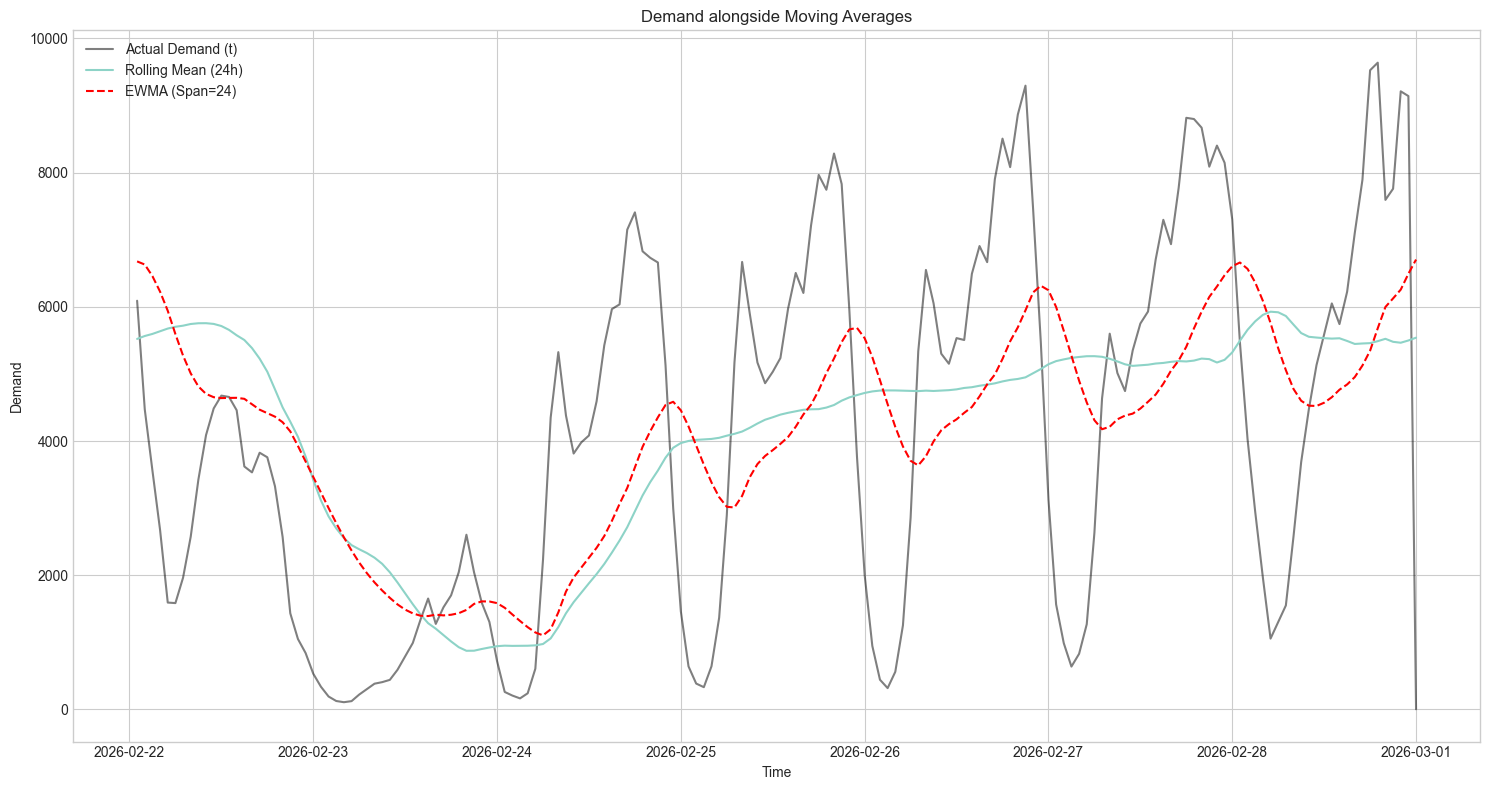

In [9]:
# We slice a small portion to keep it visible
subset = df.iloc[-168:] # Last 2 weeks

plt.figure(figsize=(15, 8))
plt.plot(subset.index, subset['total_demand'], label='Actual Demand (t)', alpha=0.5, color='black')
plt.plot(subset.index, subset['rolling_mean_24'], label='Rolling Mean (24h)')
plt.plot(subset.index, subset['ewma_span_24'], label='EWMA (Span=24)', linestyle='--', color="red")

plt.title('Demand alongside Moving Averages')
plt.xlabel('Time')
plt.ylabel('Demand')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Save Feature Set

In [7]:
# Check columns with Nulls
print(f"Total rows: {len(df)}")
print("Rows with NaNs due to shifting:", df.isna().any(axis=1).sum())

# Save the dataframe
features_path = processed_dir / "features_hourly_demand.parquet"
df.to_parquet(features_path)
print(f"Saved feature-engineered dataset to {features_path}")

Total rows: 10177
Rows with NaNs due to shifting: 168
Saved feature-engineered dataset to ..\data\processed\features_hourly_demand.parquet
